In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Caricamento del dataset e analisi della struttura

In [ ]:
def load_dataset(filename="weatherAUS.csv", cartella="dataset"):
    for base in [Path.cwd(), *Path.cwd().parents]:
        file = base / cartella / filename
        if file.exists():
            return file
    raise FileNotFoundError(
        f"'{cartella}/{filename}' non trovato. Scarica il dataset da Kaggle "
        f"e mettilo nella cartella '{cartella}/' nella root del progetto."
    )

DATA_PATH = load_dataset()
df = pd.read_csv(DATA_PATH, parse_dates=["Date"], na_values="NA")

In [3]:
print("Righe e colonne:", df.shape)
print("Periodo:", df["Date"].min().date(), "->", df["Date"].max().date())
print("N. localita:", df["Location"].nunique())
df.info()

Righe e colonne: (145460, 23)
Periodo: 2007-11-01 -> 2017-06-25
N. localita: 49
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  object        
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  object        
 8   WindGustSpeed  135197 non-null  float64       
 9   WindDir9am     134894 non-null  object        
 10  WindDir3pm     141232 non-null  object        
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 no

In [4]:
df.describe()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145460,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,2013-04-04 21:08:51.907053568,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
min,2007-11-01 00:00:00,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,2011-01-11 00:00:00,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,2013-06-02 00:00:00,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,2015-06-14 00:00:00,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,2017-06-25 00:00:00,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000
std,NaN,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665


## Analisi dei valori mancanti

In [5]:
missing = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
missing = missing[missing > 0]
for col, pct in missing.items():
    print(f"La colonna '{col}' ha {pct}% di valori mancanti.")

La colonna 'Sunshine' ha 48.01% di valori mancanti.
La colonna 'Evaporation' ha 43.17% di valori mancanti.
La colonna 'Cloud3pm' ha 40.81% di valori mancanti.
La colonna 'Cloud9am' ha 38.42% di valori mancanti.
La colonna 'Pressure9am' ha 10.36% di valori mancanti.
La colonna 'Pressure3pm' ha 10.33% di valori mancanti.
La colonna 'WindDir9am' ha 7.26% di valori mancanti.
La colonna 'WindGustDir' ha 7.1% di valori mancanti.
La colonna 'WindGustSpeed' ha 7.06% di valori mancanti.
La colonna 'Humidity3pm' ha 3.1% di valori mancanti.
La colonna 'WindDir3pm' ha 2.91% di valori mancanti.
La colonna 'Temp3pm' ha 2.48% di valori mancanti.
La colonna 'RainTomorrow' ha 2.25% di valori mancanti.
La colonna 'Rainfall' ha 2.24% di valori mancanti.
La colonna 'RainToday' ha 2.24% di valori mancanti.
La colonna 'WindSpeed3pm' ha 2.11% di valori mancanti.
La colonna 'Humidity9am' ha 1.82% di valori mancanti.
La colonna 'WindSpeed9am' ha 1.21% di valori mancanti.
La colonna 'Temp9am' ha 1.21% di valori

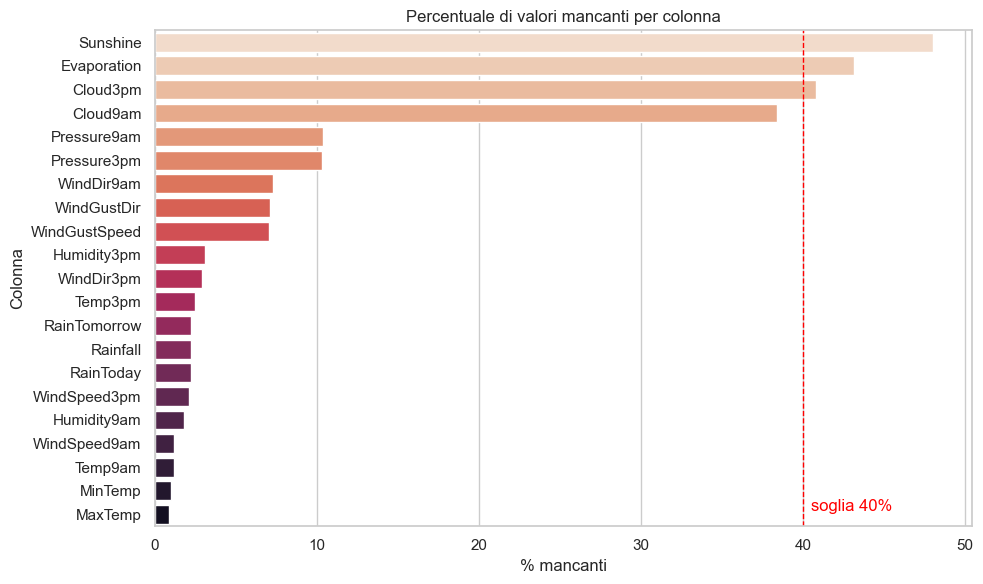

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x=missing.values, y=missing.index, hue=missing.index,
            palette="rocket_r", legend=False)
plt.title("Percentuale di valori mancanti per colonna")
plt.xlabel("% mancanti")
plt.ylabel("Colonna")
plt.axvline(40, color="red", ls="--", lw=1)
plt.text(40.5, len(missing)-1, "soglia 40%", color="red", va="bottom")
plt.tight_layout()
plt.show()

### I mancanti sono strutturali (per intere località)

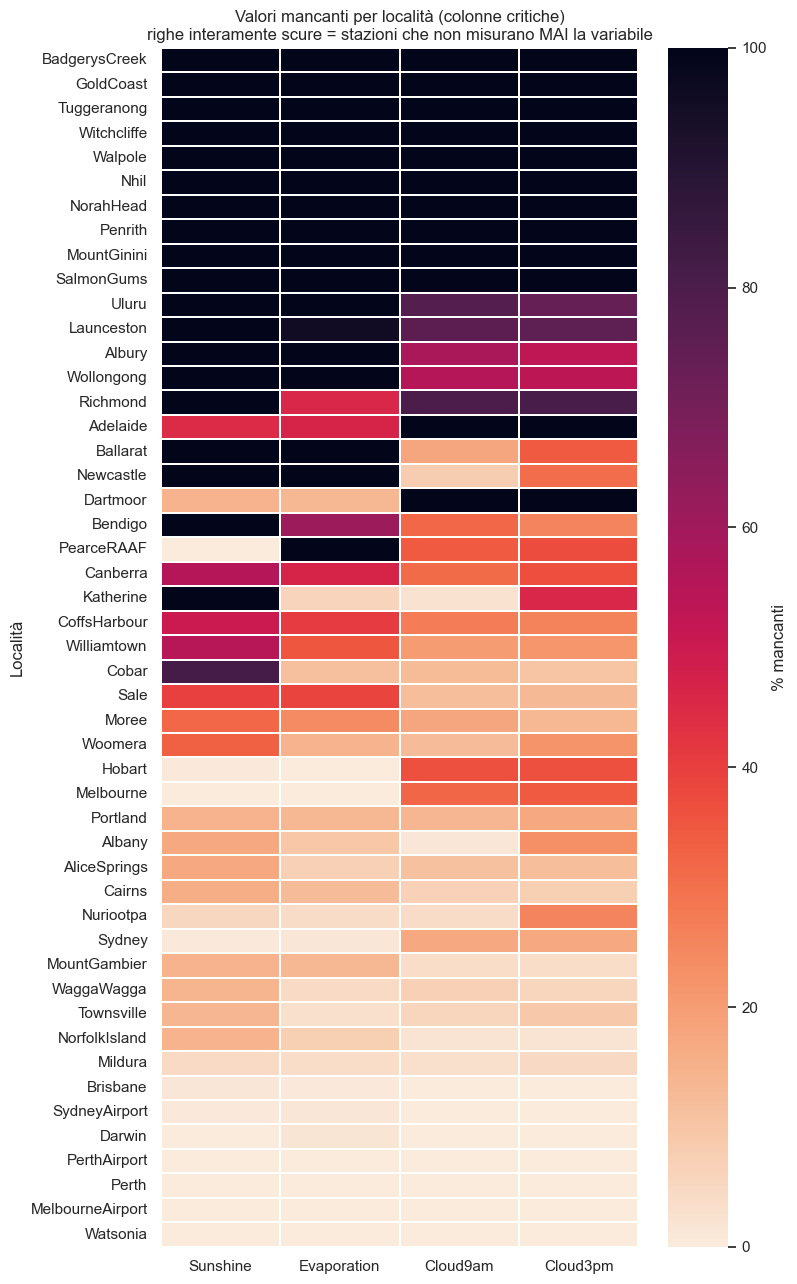

Località che non misurano MAI la variabile (100% mancante):
  Sunshine    : 19/49 località
  Evaporation : 16/49 località
  Cloud9am    : 12/49 località
  Cloud3pm    : 12/49 località


In [7]:
critiche = ["Sunshine", "Evaporation", "Cloud9am", "Cloud3pm"]

# % di mancanti per ogni località su ciascuna colonna critica
miss_loc = (df[critiche].isna().groupby(df["Location"]).mean() * 100)
# ordina le località dalla più incompleta alla più completa
miss_loc = miss_loc.loc[miss_loc.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(8, 13))
sns.heatmap(miss_loc, cmap="rocket_r", vmin=0, vmax=100,
            cbar_kws={"label": "% mancanti"}, linewidths=.3, linecolor="white")
plt.title("Valori mancanti per località (colonne critiche)\n"
          "righe interamente scure = stazioni che non misurano MAI la variabile")
plt.xlabel(""); plt.ylabel("Località")
plt.tight_layout()
plt.show()

# Riepilogo numerico: quante località non misurano la variabile
print("Località che non misurano MAI la variabile (100% mancante):")
n_loc = df["Location"].nunique()
for c in critiche:
    n = (miss_loc[c] > 99).sum()
    print(f"  {c:12s}: {n}/{n_loc} località")

## Rimozione delle righe senza target RainTomorrow

In [8]:
prima = len(df)
df = df.dropna(subset=["RainTomorrow"]).copy()
print(f"Righe prima: {prima}  ->  dopo dropna sul target: {len(df)}  (rimosse {prima - len(df)})")

Righe prima: 145460  ->  dopo dropna sul target: 142193  (rimosse 3267)


## Encoding delle variabili categoriche binarie

- `RainToday` e `RainTomorrow`: `Yes/No` → `1/0`.
- Le direzioni del vento (`WindGustDir`, `WindDir9am`, `WindDir3pm`) sono 16 classi cardinali:
  si lasciano come stringhe per i grafici di questo notebook; il **one-hot encoding** verrà fatto
  nella fase di modellazione.

In [9]:
# mappatura delle variabili categoriche binarie in 0/1
binary_map = {"No": 0, "Yes": 1}
df["RainToday"] = df["RainToday"].map(binary_map)
df["RainTomorrow"] = df["RainTomorrow"].map(binary_map)
df[["RainToday", "RainTomorrow"]].head()

,RainToday,RainTomorrow
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


## Distribuzione del target — sbilanciamento delle classi

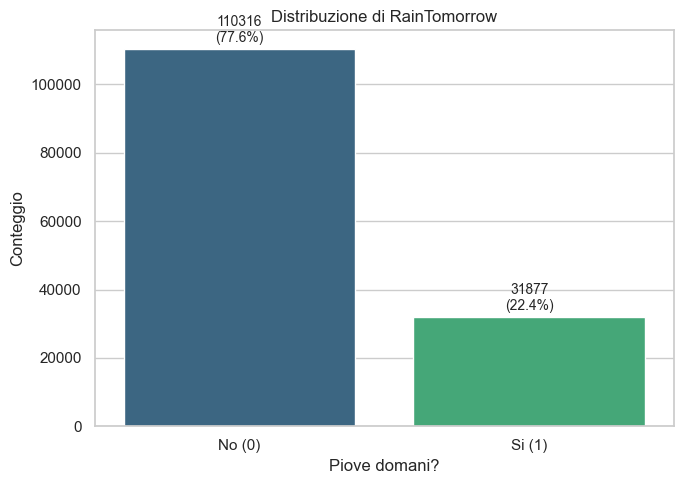

In [10]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="RainTomorrow", data=df, hue="RainTomorrow",
                   palette="viridis", legend=False)
ax.set_xticks([0, 1]); ax.set_xticklabels(["No (0)", "Si (1)"])
plt.title("Distribuzione di RainTomorrow")
plt.xlabel("Piove domani?"); plt.ylabel("Conteggio")

tot = len(df)
for p in ax.patches:
    h = int(p.get_height())
    ax.annotate(f"{h}\n({h/tot*100:.1f}%)",
                (p.get_x() + p.get_width()/2., h),
                ha="center", va="bottom", fontsize=10, xytext=(0, 3),
                textcoords="offset points")
plt.tight_layout()
plt.show()

## Distribuzione delle variabili numeriche

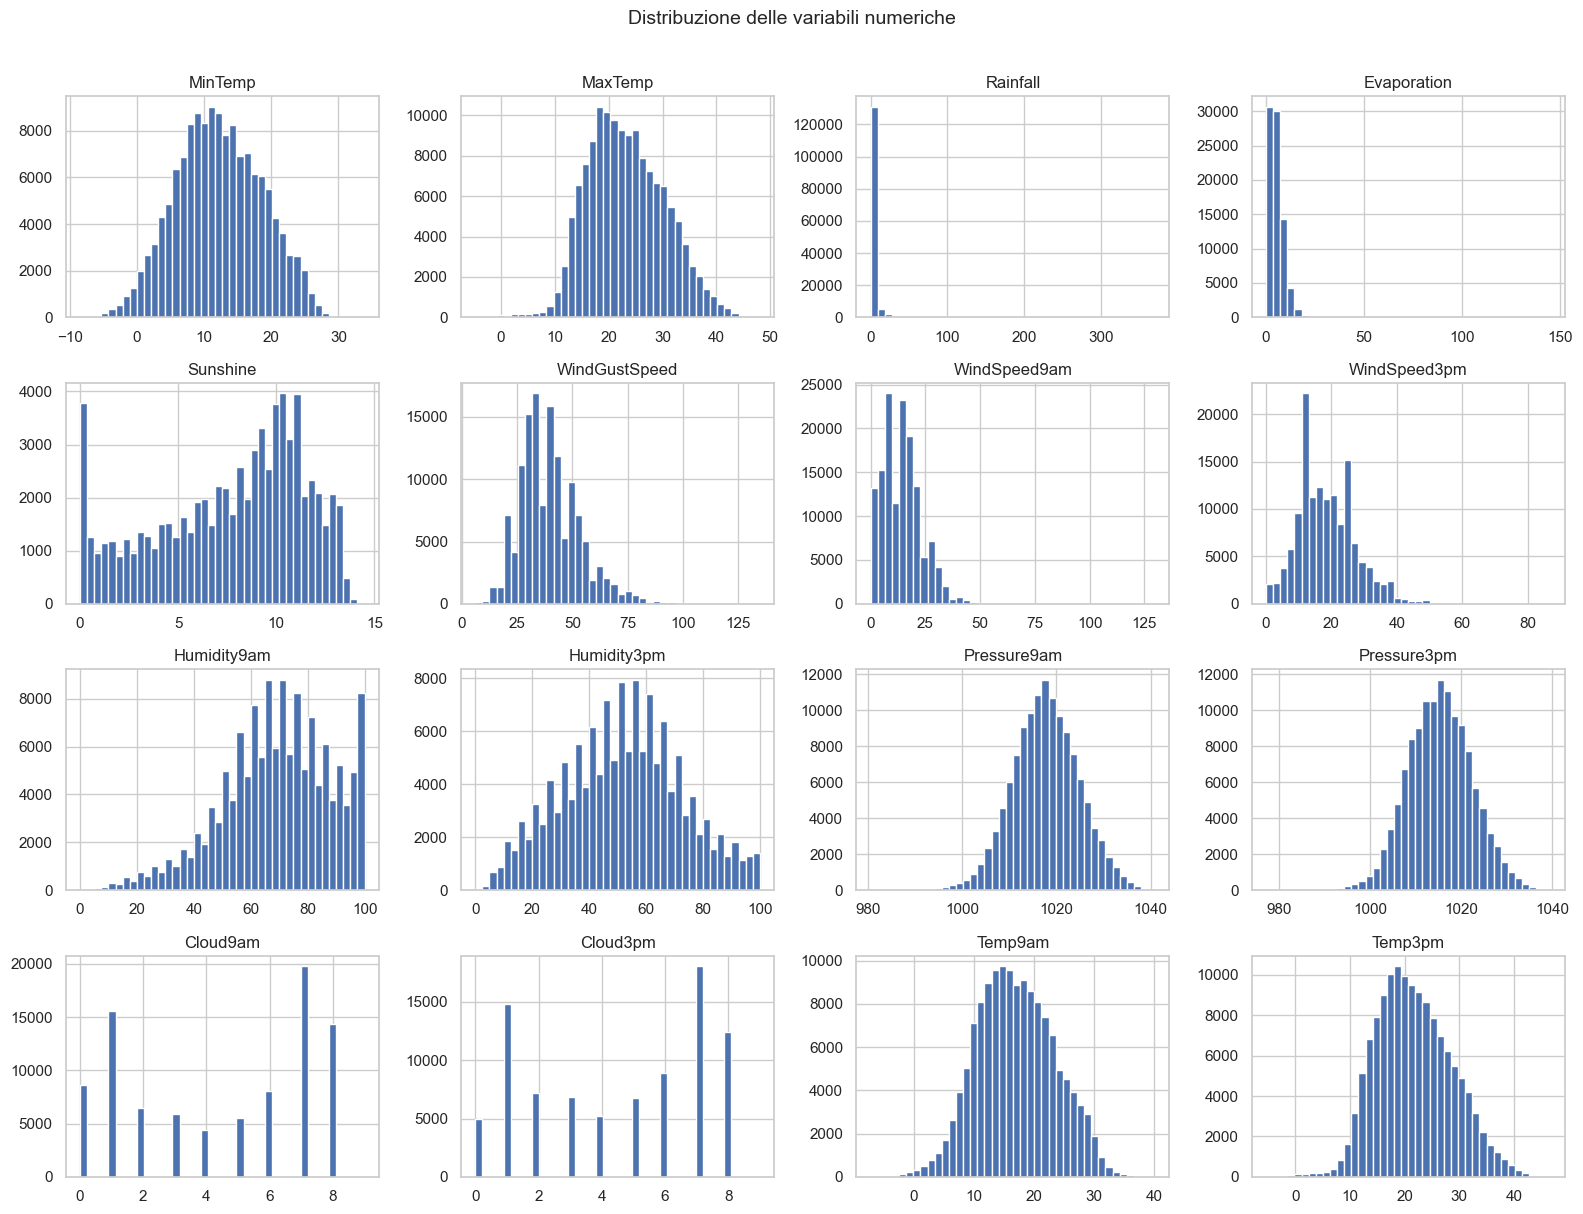

In [11]:
num_cols = df.select_dtypes(include="number").columns.drop(["RainToday", "RainTomorrow"])
df[num_cols].hist(bins=40, figsize=(16, 12), color="#4C72B0", edgecolor="white")
plt.suptitle("Distribuzione delle variabili numeriche", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Matrice di correlazione

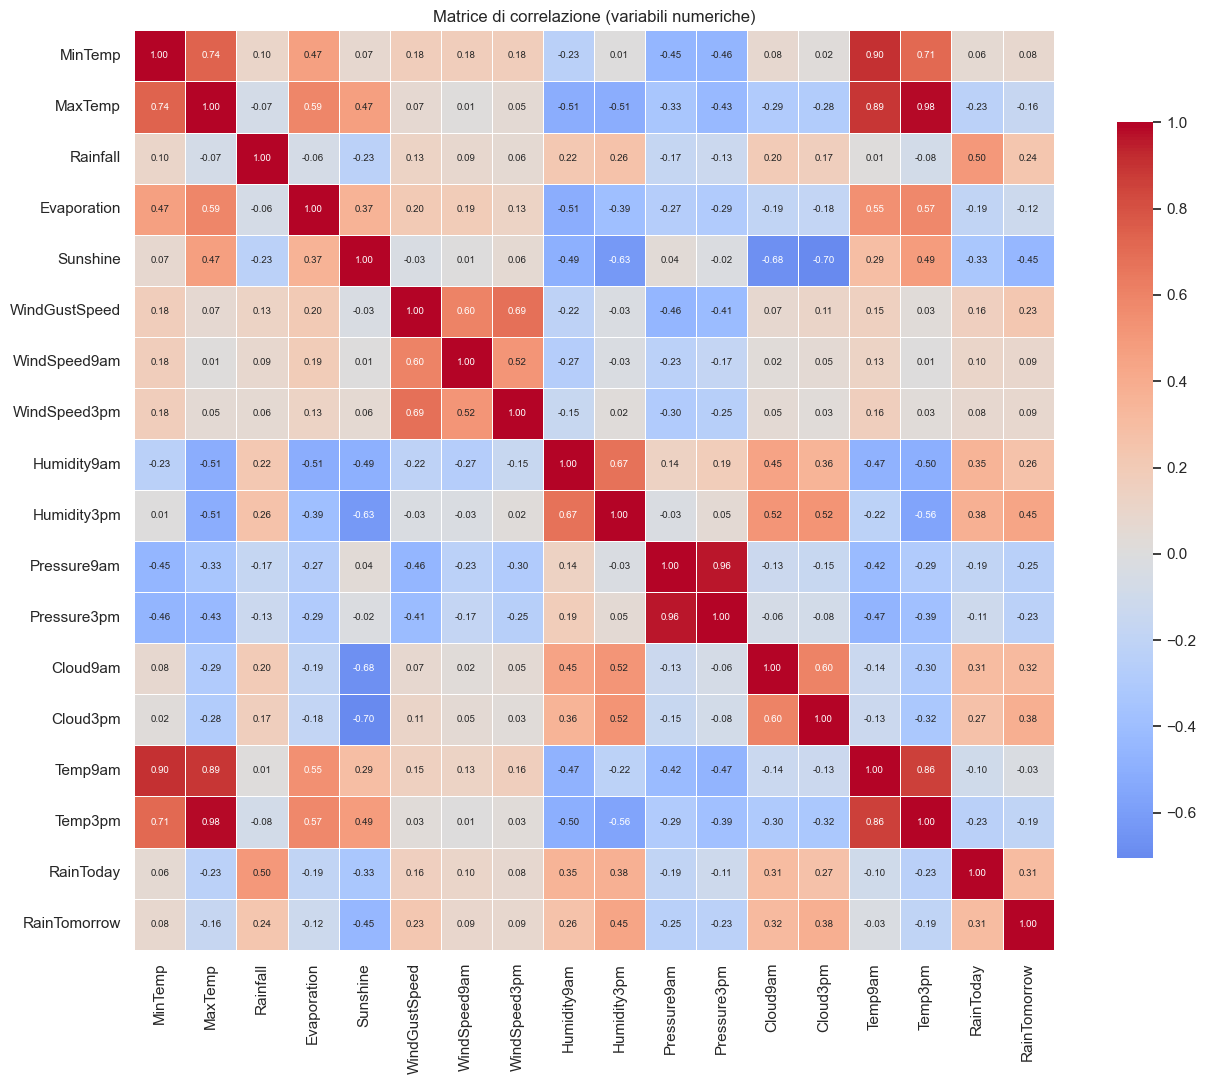

In [12]:
plt.figure(figsize=(14, 11))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, annot_kws={"size": 7},
            cbar_kws={"shrink": .8})
plt.title("Matrice di correlazione (variabili numeriche)")
plt.tight_layout()
plt.show()

In [13]:
# Variabili piu correlate (in valore assoluto) con il target
target_corr = corr["RainTomorrow"].drop("RainTomorrow").abs().sort_values(ascending=False)
print("Correlazione |assoluta| con RainTomorrow:")
print(target_corr.round(3).to_string())

Correlazione |assoluta| con RainTomorrow:
Sunshine         0.451
Humidity3pm      0.446
Cloud3pm         0.382
Cloud9am         0.317
RainToday        0.313
Humidity9am      0.257
Pressure9am      0.246
Rainfall         0.239
WindGustSpeed    0.234
Pressure3pm      0.226
Temp3pm          0.192
MaxTemp          0.159
Evaporation      0.119
WindSpeed9am     0.091
WindSpeed3pm     0.088
MinTemp          0.084
Temp9am          0.026


## Relazione tra le variabili meteo più informative e `RainTomorrow`

Boxplot delle variabili più correlate col target, separate per giorni senza e con pioggia il giorno dopo.


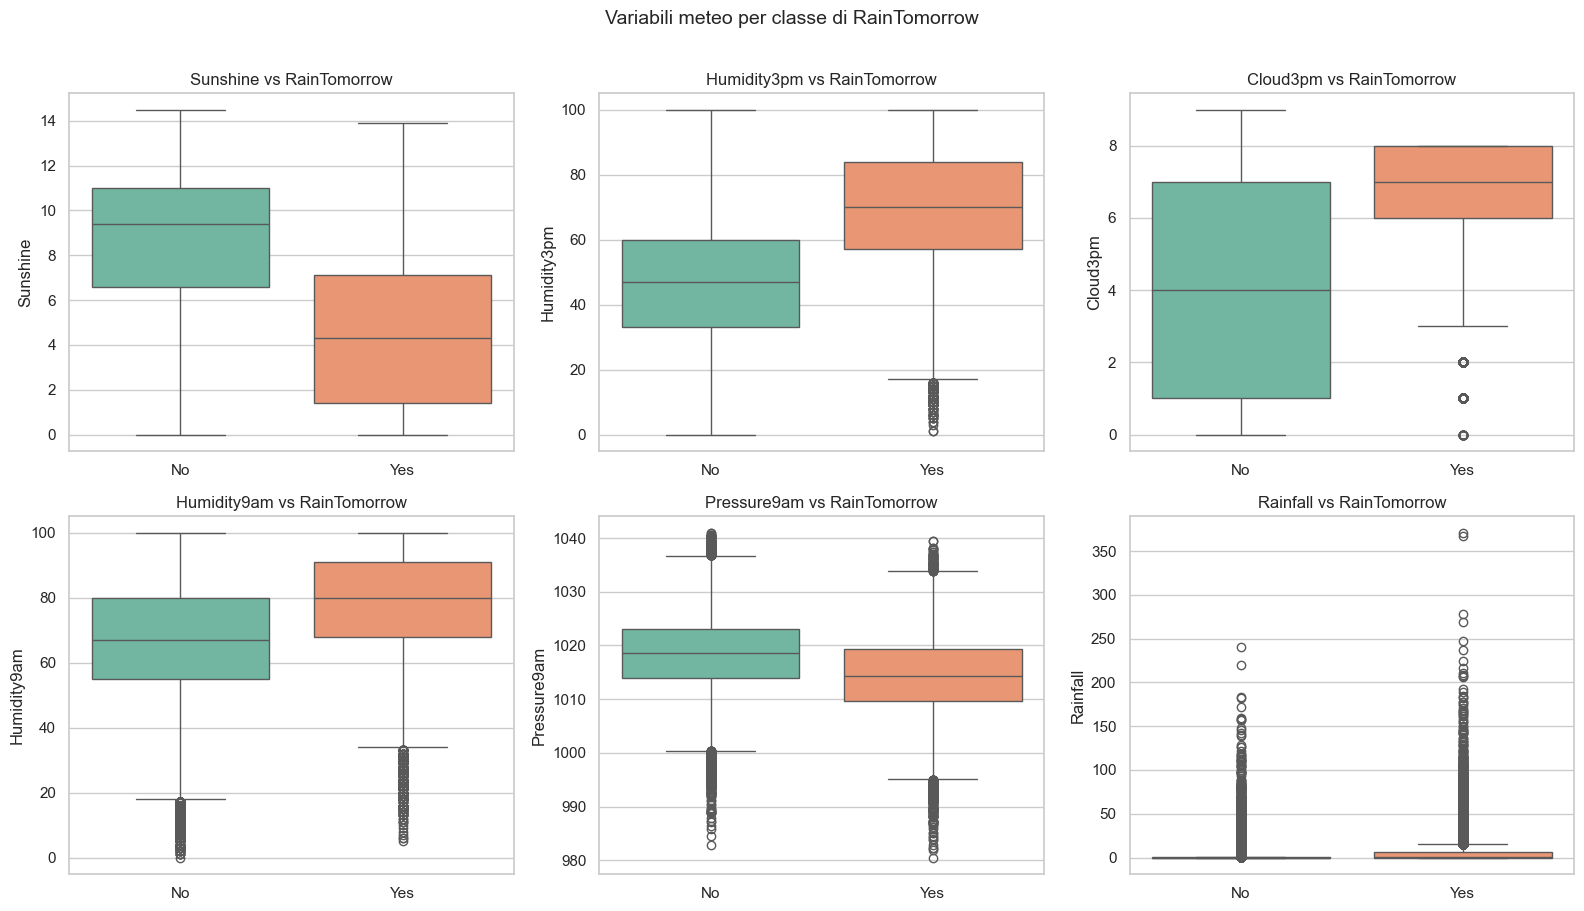

In [14]:
top_vars = ["Sunshine", "Humidity3pm", "Cloud3pm", "Humidity9am", "Pressure9am", "Rainfall"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), top_vars):
    sns.boxplot(x="RainTomorrow", y=col, data=df, hue="RainTomorrow",
                palette="Set2", legend=False, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No", "Yes"])
    ax.set_title(f"{col} vs RainTomorrow")
    ax.set_xlabel("")
plt.suptitle("Variabili meteo per classe di RainTomorrow", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## `RainToday` vs `RainTomorrow`

Persistenza della pioggia: se ha piovuto oggi, quanto è probabile che piova anche domani?

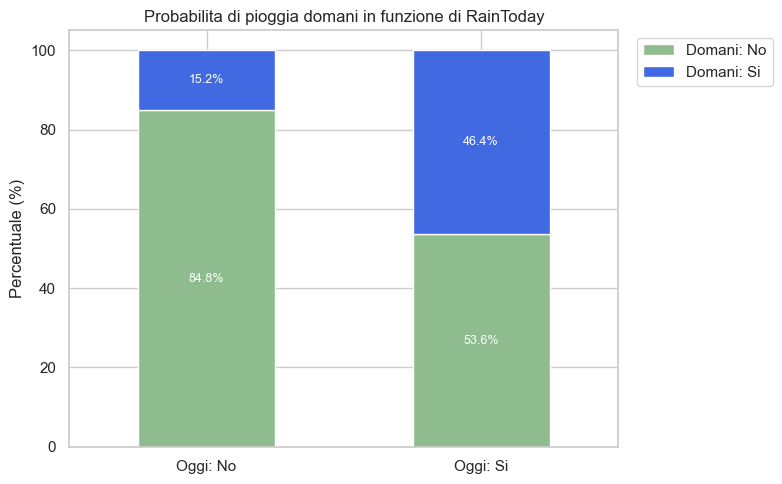

In [15]:
ct = pd.crosstab(df["RainToday"], df["RainTomorrow"], normalize="index") * 100
ct = ct.rename(index={0: "Oggi: No", 1: "Oggi: Si"},
               columns={0: "Domani: No", 1: "Domani: Si"})
ax = ct.plot(kind="bar", stacked=True, figsize=(8, 5),
             color=["#8FBC8F", "#4169E1"])
plt.title("Probabilita di pioggia domani in funzione di RainToday")
plt.ylabel("Percentuale (%)"); plt.xlabel("")
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center", color="white", fontsize=9)
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Direzione della raffica di vento e pioggia

Frequenza di pioggia (media di `RainTomorrow`) per ciascuna direzione della raffica più forte.

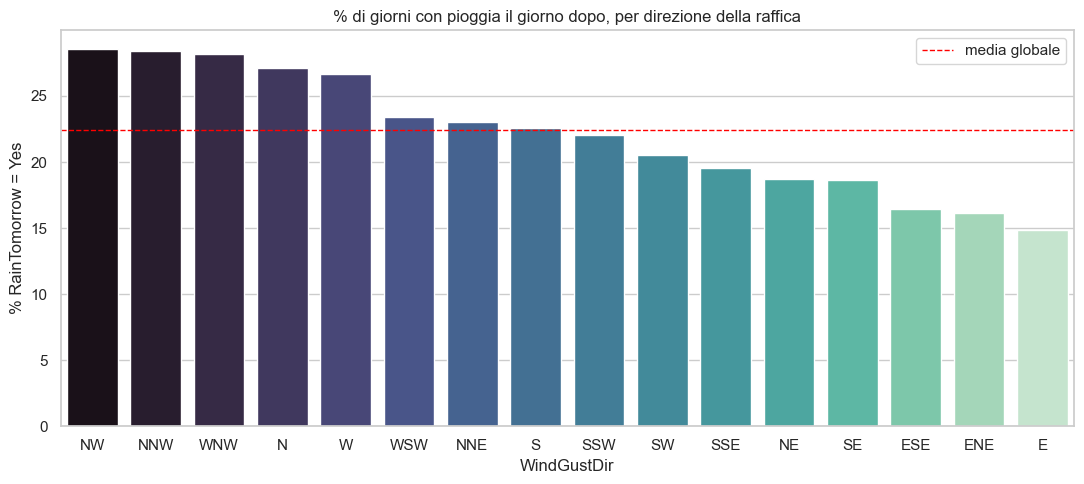

In [16]:
rain_by_dir = (df.groupby("WindGustDir")["RainTomorrow"].mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(11, 5))
sns.barplot(x=rain_by_dir.index, y=rain_by_dir.values,
            hue=rain_by_dir.index, palette="mako", legend=False)
plt.axhline(df["RainTomorrow"].mean()*100, color="red", ls="--", lw=1, label="media globale")
plt.title("% di giorni con pioggia il giorno dopo, per direzione della raffica")
plt.ylabel("% RainTomorrow = Yes"); plt.xlabel("WindGustDir")
plt.legend()
plt.tight_layout()
plt.show()

## Stagionalità
Estraiamo il mese dalla data e guardiamo la frequenza di pioggia mese per mese.
Qui il mese è usato come feature categorica statica (stagionalità), non come indice temporale.

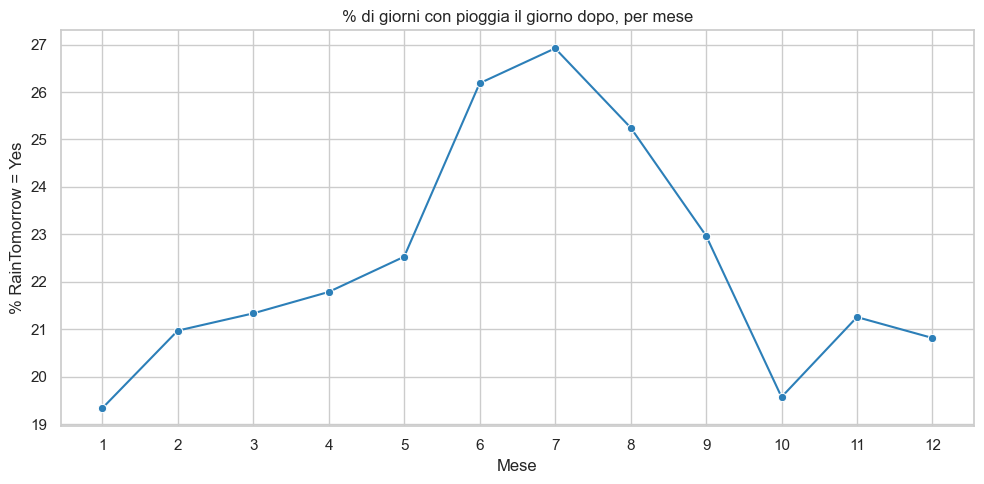

In [17]:
df["Month"] = df["Date"].dt.month
rain_by_month = df.groupby("Month")["RainTomorrow"].mean() * 100
plt.figure(figsize=(10, 5))
sns.lineplot(x=rain_by_month.index, y=rain_by_month.values, marker="o", color="#2C7FB8")
plt.title("% di giorni con pioggia il giorno dopo, per mese")
plt.xlabel("Mese"); plt.ylabel("% RainTomorrow = Yes")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Differenze tra località

La frequenza di pioggia varia molto da città a città: utile per decidere se includere `Location`
come feature (one-hot encoding) o costruire un modello "solo meteo".

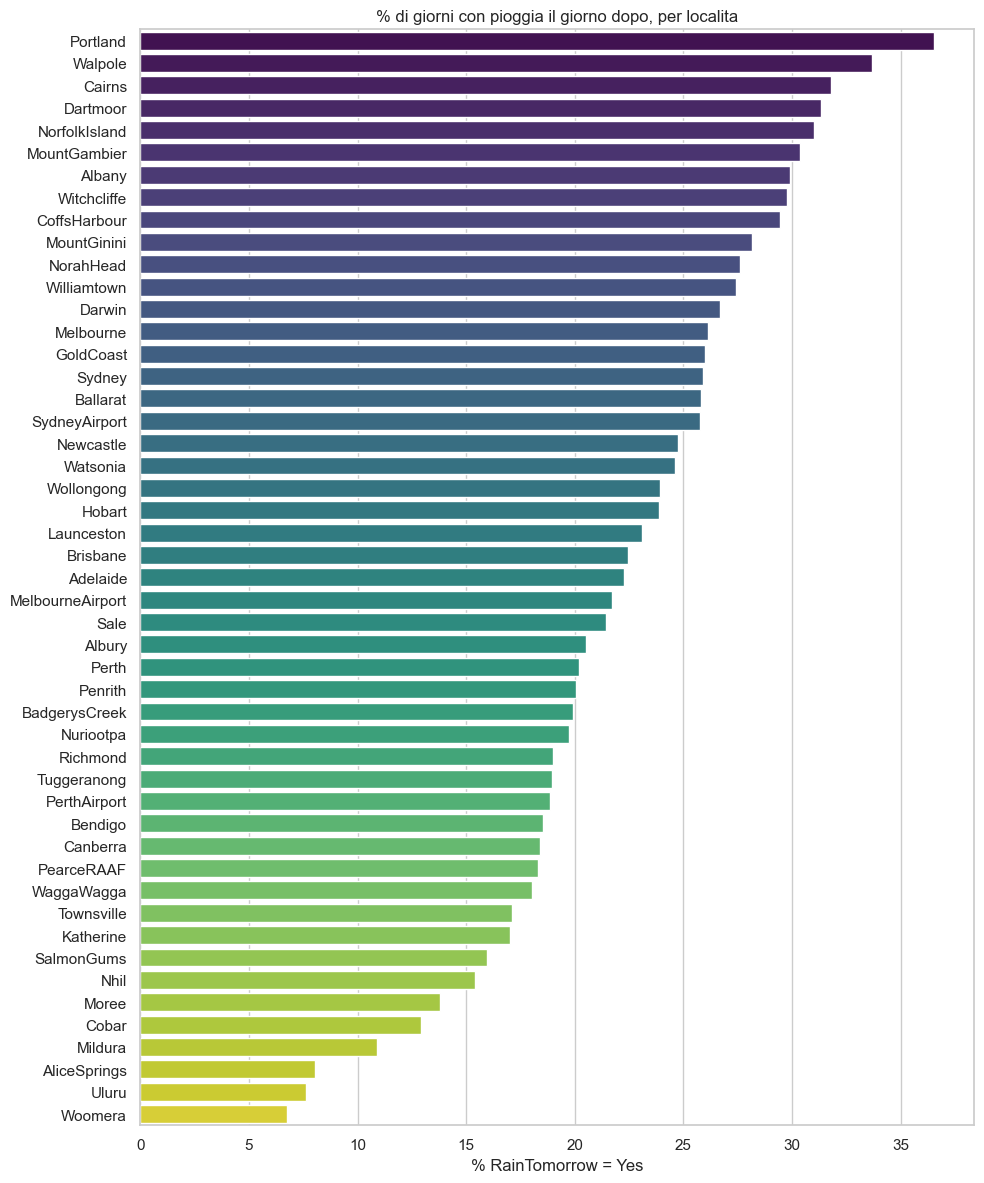

In [18]:
rain_by_loc = (df.groupby("Location")["RainTomorrow"].mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 12))
sns.barplot(x=rain_by_loc.values, y=rain_by_loc.index,
            hue=rain_by_loc.index, palette="viridis", legend=False)
plt.title("% di giorni con pioggia il giorno dopo, per localita")
plt.xlabel("% RainTomorrow = Yes"); plt.ylabel("")
plt.tight_layout()
plt.show()